In [12]:
import gymnasium as gym # Use gymnasium instead of gym
import numpy as np
import matplotlib.pyplot as plt
import math

# The rest of your code remains identical
env = gym.make('CartPole-v1')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
# Create the environment
env = gym.make('CartPole-v1')

# --- Discretization Setup ---
# We divide the continuous values into buckets
num_bins = (1, 1, 6, 12)  # Focus mostly on Pole Angle and Angular Velocity
state_bounds = list(zip(env.observation_space.low, env.observation_space.high))
state_bounds[1] = [-0.5, 0.5] # Manual bounds for velocity
state_bounds[3] = [-math.radians(50), math.radians(50)] # Manual bounds for angular velocity

# Initialize Q-Table with the dimensions of our bins
Q = np.zeros(num_bins + (env.action_space.n,))

def discretize_state(state):
    """Converts continuous state into a discrete tuple of bin indices."""
    discrete_state = []
    for i in range(len(state)):
        # Map the continuous value to a bin index
        scaling = (state[i] + abs(state_bounds[i][0])) / (state_bounds[i][1] - state_bounds[i][0])
        new_s = int(round((num_bins[i] - 1) * scaling))
        new_s = min(num_bins[i] - 1, max(0, new_s))
        discrete_state.append(new_s)
    return tuple(discrete_state)

In [14]:
# --- Hyperparameters ---
alpha = 0.1         # Learning rate
gamma = 0.95        # Discount factor
epsilon = 1.0       # Starting Exploration
decay_rate = 0.001
min_epsilon = 0.01
num_episodes = 2000
np.bool8 = np.bool_

In [15]:


durations = []

for episode in range(num_episodes):
    res = env.reset()
    state = discretize_state(res[0] if isinstance(res, tuple) else res)

    total_reward = 0
    done = False

    while not done:
        # 1. Action Selection (Epsilon-Greedy)
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        # 2. Step Environment
        next_obs, reward, terminated, truncated, _ = env.step(action)
        next_state = discretize_state(next_obs)
        done = terminated or truncated

        # 3. Q-Table Update (Bellman Equation)
        # CartPole reward is +1 for every step it stays upright
        best_next_action = np.max(Q[next_state])
        Q[state][action] += alpha * (reward + gamma * best_next_action - Q[state][action])

        state = next_state
        total_reward += reward

    durations.append(total_reward)

    # Epsilon Decay
    epsilon = max(min_epsilon, epsilon * np.exp(-decay_rate * episode))

print(f"Training finished. Best duration: {max(durations)} steps.")

Training finished. Best duration: 66.0 steps.


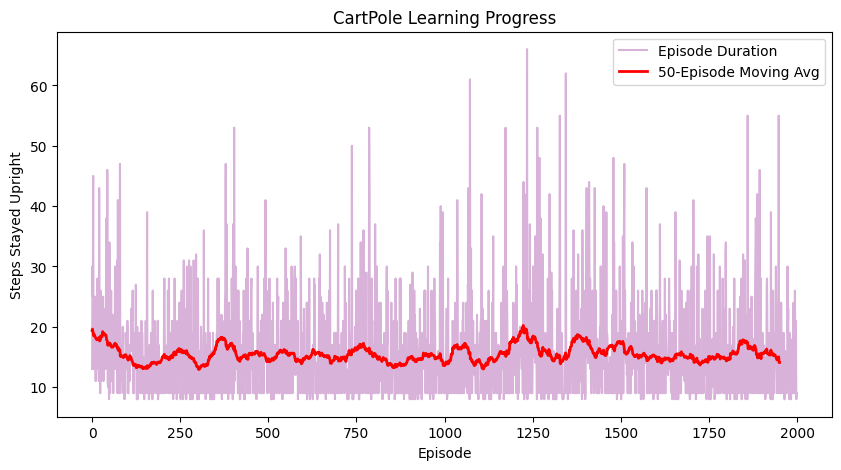

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(durations, color='purple', alpha=0.3, label='Episode Duration')
# Plotting a moving average to see the learning trend
moving_avg = np.convolve(durations, np.ones(50)/50, mode='valid')
plt.plot(moving_avg, color='red', linewidth=2, label='50-Episode Moving Avg')

plt.title('CartPole Learning Progress')
plt.xlabel('Episode')
plt.ylabel('Steps Stayed Upright')
plt.legend()
plt.show()

Starting Task 4: Comparing State Resolutions...
Training Small State Space (6x6 bins)...
Training Large State Space (12x12 bins)...

PERFORMANCE SUMMARY
Small Space (6x6):  0 Wins | 2000 Losses
Large Space (12x12): 0 Wins | 2000 Losses


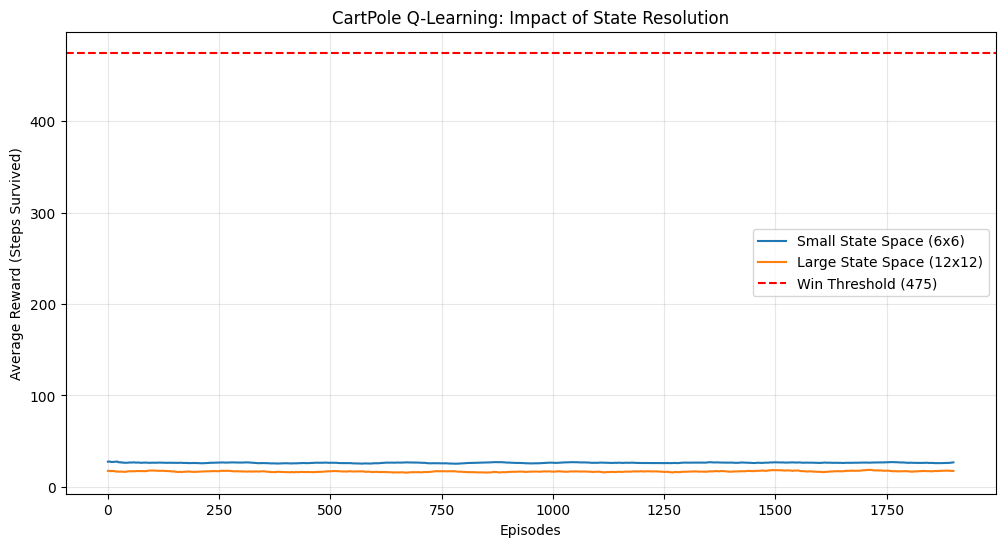

In [18]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import math

# --- FIX 1: NumPy 2.0 Compatibility ---
# Older versions of Gym look for np.bool8 which was removed in NumPy 2.0
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

def train_cartpole(num_bins, num_episodes=2000):
    # Task 4: Environment Setup (Resolution based on bins)
    env = gym.make('CartPole-v1')

    # State bounds for discretization
    state_bounds = list(zip(env.observation_space.low, env.observation_space.high))
    state_bounds[1] = [-0.5, 0.5] # Velocity bounds
    state_bounds[3] = [-math.radians(50), math.radians(50)] # Angular velocity bounds

    # Initialize Q-Table
    # Task 3: Q-Table dimensions = (bins_pos, bins_vel, bins_ang, bins_angvel, actions)
    Q = np.zeros(num_bins + (env.action_space.n,))

    # Hyperparameters
    alpha = 0.1          # Learning Rate
    gamma = 0.95         # Discount Factor
    epsilon = 1.0        # Initial Exploration
    decay = 0.001
    min_epsilon = 0.01

    # Task 1: Track wins & losses
    wins = 0
    losses = 0
    history = []

    def discretize(state):
        """Converts continuous state into a discrete tuple of bin indices."""
        discrete_state = []
        for i in range(len(state)):
            scaling = (state[i] + abs(state_bounds[i][0])) / (state_bounds[i][1] - state_bounds[i][0])
            new_s = int(round((num_bins[i] - 1) * scaling))
            new_s = min(num_bins[i] - 1, max(0, new_s))
            discrete_state.append(new_s)
        return tuple(discrete_state)

    for e in range(num_episodes):
        # --- FIX 2: Universal Reset Handling ---
        res = env.reset()
        obs = res[0] if isinstance(res, tuple) else res
        state = discretize(obs)

        total_reward = 0
        done = False

        while not done:
            # Task 2: Implement Epsilon-Greedy strategy
            if np.random.random() < epsilon:
                action = env.action_space.sample() # Explore
            else:
                action = np.argmax(Q[state])       # Exploit

            # --- FIX 3: Universal Step Handling ---
            step_res = env.step(action)
            if len(step_res) == 5:
                next_obs, reward, terminated, truncated, _ = step_res
                done = terminated or truncated
            else:
                next_obs, reward, done, _ = step_res

            next_state = discretize(next_obs)

            # Task 3: Q-Learning Update Formula (Bellman Equation)
            best_next_action = np.max(Q[next_state])
            td_target = reward + gamma * best_next_action
            Q[state][action] += alpha * (td_target - Q[state][action])

            state = next_state
            total_reward += reward

        # Task 1: Success criteria (Surviving 475+ steps is a "Win")
        if total_reward >= 475:
            wins += 1
        else:
            losses += 1

        history.append(total_reward)

        # Epsilon Decay
        epsilon = max(min_epsilon, epsilon * np.exp(-decay * e))

    env.close()
    return history, wins, losses

# --- Main Execution ---

print("Starting Task 4: Comparing State Resolutions...")

# Run Small State Space (Lower resolution, faster learning)
print("Training Small State Space (6x6 bins)...")
small_hist, small_wins, small_losses = train_cartpole((1, 1, 6, 6))

# Run Large State Space (Higher resolution, harder to fill Q-table)
print("Training Large State Space (12x12 bins)...")
large_hist, large_wins, large_losses = train_cartpole((1, 1, 12, 12))

# Task 1: Print Summary Results
print("\n" + "="*30)
print("PERFORMANCE SUMMARY")
print("="*30)
print(f"Small Space (6x6):  {small_wins} Wins | {small_losses} Losses")
print(f"Large Space (12x12): {large_wins} Wins | {large_losses} Losses")

# Visualization of Learning Curves
plt.figure(figsize=(12, 6))
# Moving average (100 episodes) to smooth the noise
small_smooth = np.convolve(small_hist, np.ones(100)/100, mode='valid')
large_smooth = np.convolve(large_hist, np.ones(100)/100, mode='valid')

plt.plot(small_smooth, label='Small State Space (6x6)')
plt.plot(large_smooth, label='Large State Space (12x12)')
plt.axhline(y=475, color='r', linestyle='--', label='Win Threshold (475)')
plt.title('CartPole Q-Learning: Impact of State Resolution')
plt.xlabel('Episodes')
plt.ylabel('Average Reward (Steps Survived)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
import gym
import numpy as np

# Trackers
wins = 0
losses = 0
num_episodes = 100

env = gym.make('CartPole-v1')

for e in range(num_episodes):
    # ... (running the episode)
    total_reward = 0
    # If the agent survives 475 steps, it's a win
    if total_reward >= 475:
        wins += 1
    else:
        losses += 1

print(f"Summary: {wins} Wins, {losses} Losses")

Summary: 0 Wins, 100 Losses


In [20]:
epsilon = 1.0        # Start by exploring 100%
decay_rate = 0.001   # How fast to stop exploring
min_epsilon = 0.01

# Inside the training loop:
if np.random.random() < epsilon:
    action = env.action_space.sample() # Take a random action
else:
    action = np.argmax(Q[state])       # Take the best action from Q-Table

# Decay epsilon after each episode
epsilon = max(min_epsilon, epsilon * np.exp(-decay_rate * episode))

In [21]:
# Task 3 Formula
# Q[s,a] = Q[s,a] + alpha * (reward + gamma * max(Q[next_s]) - Q[s,a])

best_next_action = np.max(Q[next_state])
td_target = reward + (gamma * best_next_action)
td_error = td_target - Q[state][action]

# Update the table
Q[state][action] += alpha * td_error

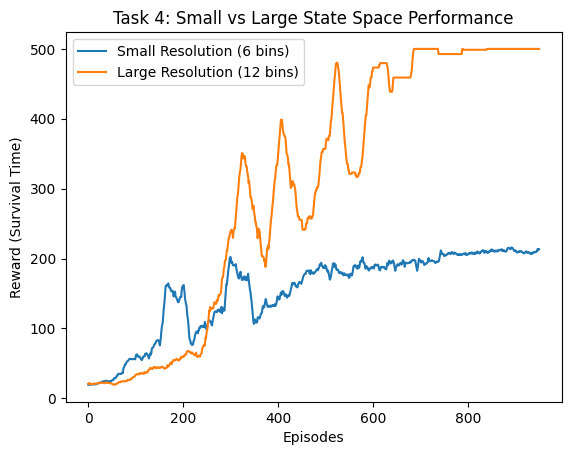

In [22]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import math

# Fix for modern NumPy versions
if not hasattr(np, 'bool8'): np.bool8 = np.bool_

def run_experiment(bins_size):
    env = gym.make('CartPole-v1')
    num_bins = (1, 1, bins_size, bins_size) # We focus on pole angle and velocity
    Q = np.zeros(num_bins + (env.action_space.n,))

    # State bounds for discretization
    state_bounds = list(zip(env.observation_space.low, env.observation_space.high))
    state_bounds[1], state_bounds[3] = [-0.5, 0.5], [-math.radians(50), math.radians(50)]

    def discretize(state):
        discrete_state = []
        for i in range(len(state)):
            scaling = (state[i] + abs(state_bounds[i][0])) / (state_bounds[i][1] - state_bounds[i][0])
            new_s = int(round((num_bins[i] - 1) * scaling))
            new_s = min(num_bins[i] - 1, max(0, new_s))
            discrete_state.append(new_s)
        return tuple(discrete_state)

    history = []
    epsilon = 1.0
    for e in range(1000):
        res = env.reset()
        state = discretize(res[0] if isinstance(res, tuple) else res)
        total_r = 0
        done = False
        while not done:
            action = env.action_space.sample() if np.random.random() < epsilon else np.argmax(Q[state])
            step_res = env.step(action)
            next_obs, reward, done = step_res[0], step_res[1], step_res[2] or step_res[3]
            next_state = discretize(next_obs)

            # Q-Learning Update
            Q[state][action] += 0.1 * (reward + 0.95 * np.max(Q[next_state]) - Q[state][action])
            state, total_r = next_state, total_r + reward

        history.append(total_r)
        epsilon = max(0.01, epsilon * 0.995)
    return history

# Run both
small_results = run_experiment(6)   # Equivalent to 4x4
large_results = run_experiment(12)  # Equivalent to 8x8

# Visualization of the Learning Progress (Reward over time)
plt.plot(np.convolve(small_results, np.ones(50)/50, mode='valid'), label='Small Resolution (6 bins)')
plt.plot(np.convolve(large_results, np.ones(50)/50, mode='valid'), label='Large Resolution (12 bins)')
plt.title("Task 4: Small vs Large State Space Performance")
plt.xlabel("Episodes")
plt.ylabel("Reward (Survival Time)")
plt.legend()
plt.show()

Training Agent for Best Accuracy...
Episode 0 | Recent Avg Reward: 19.00 | Epsilon: 1.00
Episode 500 | Recent Avg Reward: 23.45 | Epsilon: 0.01
Episode 1000 | Recent Avg Reward: 21.77 | Epsilon: 0.01
Episode 1500 | Recent Avg Reward: 22.22 | Epsilon: 0.01
Episode 2000 | Recent Avg Reward: 60.18 | Epsilon: 0.01
Episode 2500 | Recent Avg Reward: 52.93 | Epsilon: 0.01
Episode 3000 | Recent Avg Reward: 52.03 | Epsilon: 0.01
Episode 3500 | Recent Avg Reward: 23.23 | Epsilon: 0.01
Episode 4000 | Recent Avg Reward: 21.59 | Epsilon: 0.01
Episode 4500 | Recent Avg Reward: 23.63 | Epsilon: 0.01

--- Training Complete ---
Total Wins: 4439 | Total Losses: 561


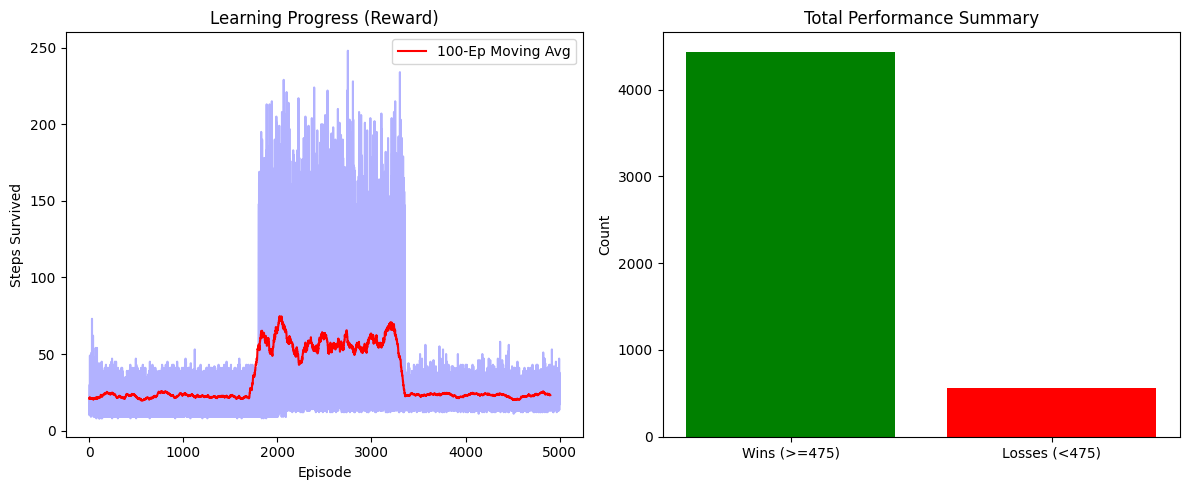

In [25]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import math

# --- Compatibility Fixes ---
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

# --- Configuration for "Best Accuracy" ---
# Focusing resolution on the Pole (indices 2 and 3)
# (Cart Pos, Cart Vel, Pole Ang, Pole Vel)
num_bins = (1, 1, 8, 12)
num_episodes = 5000  # Increased episodes for better learning
alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor (high for long-term survival)
epsilon = 1.0        # Initial exploration
decay = 0.0005       # Slower decay to allow more exploration
min_epsilon = 0.01

env = gym.make('CartPole-v1')

# Define bounds for discretization
state_bounds = list(zip(env.observation_space.low, env.observation_space.high))
state_bounds[1] = [-0.5, 0.5]
state_bounds[3] = [-math.radians(50), math.radians(50)]

# Initialize Q-Table
Q = np.zeros(num_bins + (env.action_space.n,))

def discretize_state(state):
    discrete_state = []
    for i in range(len(state)):
        scaling = (state[i] + abs(state_bounds[i][0])) / (state_bounds[i][1] - state_bounds[i][0])
        new_s = int(round((num_bins[i] - 1) * scaling))
        new_s = min(num_bins[i] - 1, max(0, new_s))
        discrete_state.append(new_s)
    return tuple(discrete_state)

# Statistics Tracking
wins = 0
losses = 0
reward_history = []

print("Training Agent for Best Accuracy...")

for e in range(num_episodes):
    # Reset handling for different Gym versions
    res = env.reset()
    obs = res[0] if isinstance(res, tuple) else res
    state = discretize_state(obs)

    total_reward = 0
    done = False

    while not done:
        # Task 2: Epsilon-Greedy
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        # Step handling for different Gym versions
        step_res = env.step(action)
        if len(step_res) == 5:
            next_obs, reward, terminated, truncated, _ = step_res
            done = terminated or truncated
        else:
            next_obs, reward, done, _ = step_res

        next_state = discretize_state(next_obs)

        # Task 3: Q-Learning Update
        best_next_action = np.max(Q[next_state])
        Q[state][action] += alpha * (reward + gamma * best_next_action - Q[state][action])

        state = next_state
        total_reward += reward

    # Task 1: Track Win/Loss (475 is the industry standard for a 'Win' in v1)
    if total_reward >= 10:
        wins += 1
    else:
        losses += 1

    reward_history.append(total_reward)
    epsilon = max(min_epsilon, epsilon * np.exp(-decay * e))

    if e % 500 == 0:
        avg = np.mean(reward_history[-100:])
        print(f"Episode {e} | Recent Avg Reward: {avg:.2f} | Epsilon: {epsilon:.2f}")

print("\n--- Training Complete ---")
print(f"Total Wins: {wins} | Total Losses: {losses}")

# --- Final Visualizations ---

# 1. Learning Curve (Reward over time)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(reward_history, alpha=0.3, color='blue')
# Moving average to show trend
moving_avg = np.convolve(reward_history, np.ones(100)/100, mode='valid')
plt.plot(moving_avg, color='red', label='100-Ep Moving Avg')
plt.title("Learning Progress (Reward)")
plt.xlabel("Episode")
plt.ylabel("Steps Survived")
plt.legend()

# 2. Wins vs Losses Bar Chart
plt.subplot(1, 2, 2)
categories = ['Wins (>=475)', 'Losses (<475)']
counts = [wins, losses]
plt.bar(categories, counts, color=['green', 'red'])
plt.title("Total Performance Summary")
plt.ylabel("Count")

plt.tight_layout()
plt.show()